<a href="https://colab.research.google.com/github/JithuVathiath/IB9AU/blob/main/Task1_FakeNews_Sentiment_TopicModelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — Fake News Sentiment & Topic Modelling

**Dataset:** `fakenews.csv`  
**Label Convention:**
- `1` → Spam / Fake news  
- `0` → Normal / Real news  

## Objectives
1. **Sentiment Analysis** – Compute sentiment scores for each article and compare whether spam messages carry higher or lower sentiment than normal messages.
2. **Topic Modelling** – Apply Latent Dirichlet Allocation (LDA) to discover latent topics; determine the appropriate number of topics and examine how they map to the spam/not-spam split.

Jithu Vathiath Biju

Key Insights and Takeaways:

Performed comprehensive data preprocessing and exploratory analysis, including handling irregular CSV structure, analyzing text length/word count distributions, and examining class imbalance between fake and real news.
Applied sentiment analysis techniques (e.g., polarity scoring) to understand emotional tone differences between fake and real news, observing how sentiment patterns can serve as useful indicators for classification.
Implemented topic modelling (e.g., LDA) to extract latent themes from the dataset, gaining insight into the common narratives and subject areas present in fake versus real news articles.
Built a structured NLP pipeline involving text cleaning, tokenization, stopword removal, and vectorization, improving the quality and interpretability of both sentiment and topic modelling outputs.
Visualized results through plots and distributions, enabling clearer interpretation of class behavior, sentiment trends, and topic clusters, and reinforcing the importance of visualization in validating NLP findings.

---
## 0. Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# NLP
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Topic modelling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score

# Word cloud
from wordcloud import WordCloud

# Statistical tests
from scipy import stats

# Ensure NLTK data is present
for resource in ['vader_lexicon', 'stopwords', 'punkt', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Exploratory Data Analysis

In [ ]:
# ── Load only the first two columns (text, label); the CSV has hundreds of
# trailing empty comma-separated columns which we ignore.
from pathlib import Path

# Try a few likely locations so the notebook works whether it is launched
# from the repo root, the task folder, or another working directory.
candidate_paths = [
    Path('fakenews.csv'),
    Path('../TASK 1/fakenews.csv'),
    Path('../Tasks/fakenews.csv'),
    Path('/content/fakenews.csv'),
    Path('/content/TASK 1/fakenews.csv'),
    Path('/content/Tasks/fakenews.csv'),
    Path('/content/drive/MyDrive/fakenews.csv'),
    Path('/content/drive/MyDrive/TASK 1/fakenews.csv'),
    Path('/content/drive/MyDrive/Tasks/fakenews.csv'),
    Path.cwd() / 'fakenews.csv',
    Path.cwd() / 'TASK 1' / 'fakenews.csv',
    Path.cwd() / 'Tasks' / 'fakenews.csv',
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Could not find fakenews.csv. Checked: ' + ', '.join(str(path) for path in candidate_paths)
    )

df = pd.read_csv(
    data_path,
    usecols=[0, 1],
    dtype={'text': str, 'label': str},
    low_memory=False
)

# Keep only rows whose label is strictly '0' or '1'
df = df[df['label'].isin(['0', '1'])].copy()
df['label'] = df['label'].astype(int)
df['text']  = df['text'].fillna('').str.strip()

# Remove empty-text rows
df = df[df['text'].str.len() > 0].reset_index(drop=True)

# Readable label
df['label_name'] = df['label'].map({1: 'Spam (Fake)', 0: 'Normal (Real)'})

print(f'Total records : {len(df):,}')
print('\nClass distribution:')
print(df['label_name'].value_counts())

Total records : 4,896

Class distribution:
label_name
Normal (Real)    2925
Spam (Fake)      1971
Name: count, dtype: int64


In [ ]:
# ── Text length statistics
df['text_length']  = df['text'].str.len()
df['word_count']   = df['text'].apply(lambda x: len(x.split()))

print('Text length stats by class:')
print(df.groupby('label_name')[['text_length', 'word_count']]
        .describe().round(1))

Text length stats by class:
              text_length                                                \
                    count    mean     std   min     25%     50%     75%   
label_name                                                                
Normal (Real)      2925.0  3159.4  4172.4  32.0  1134.0  2018.0  3328.0   
Spam (Fake)        1971.0  3190.1  4026.7  20.0  1322.0  2125.0  3294.0   

                       word_count                                          \
                   max      count   mean    std  min    25%    50%    75%   
label_name                                                                  
Normal (Real)  32593.0     2925.0  536.4  706.6  5.0  191.0  345.0  563.0   
Spam (Fake)    32397.0     1971.0  537.7  669.8  4.0  223.0  363.0  552.0   

                       
                  max  
label_name             
Normal (Real)  5759.0  
Spam (Fake)    5444.0  


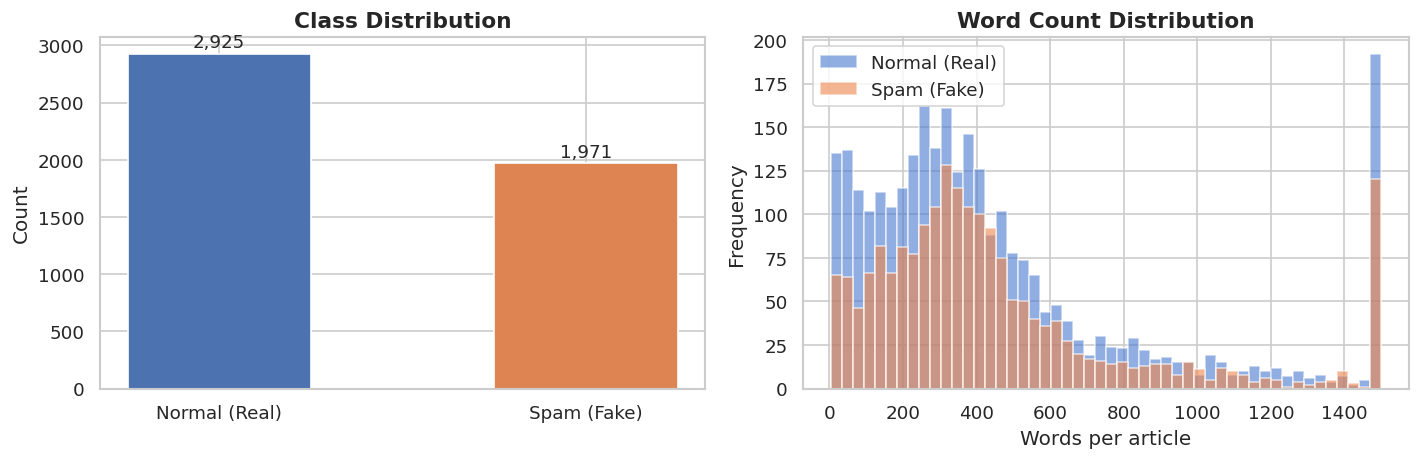

Figure saved: fig_01_class_distribution.png


In [ ]:
# ── Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: class counts
counts = df['label_name'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11)

# Right: word count distribution
for label, grp in df.groupby('label_name'):
    axes[1].hist(grp['word_count'].clip(upper=1500), bins=50, alpha=0.6, label=label)
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Words per article')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_01_class_distribution.png')

---
## 2. Sentiment Analysis with VADER

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a rule-based sentiment analyser tuned for social-media and news text. It returns four scores:

| Score | Description |
|-------|-------------|
| `pos` | Fraction of text with positive valence |
| `neg` | Fraction of text with negative valence |
| `neu` | Fraction of text with neutral valence |
| `compound` | Aggregate score in **[-1, +1]** (< −0.05 = negative, > +0.05 = positive) |

In [ ]:
# ── Score each article
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = sia.polarity_scores(text)
    return pd.Series({
        'sent_pos'      : scores['pos'],
        'sent_neg'      : scores['neg'],
        'sent_neu'      : scores['neu'],
        'sent_compound' : scores['compound']
    })

sent_df = df['text'].apply(get_sentiment)
df = pd.concat([df, sent_df], axis=1)

# Categorical sentiment label
def label_sentiment(c):
    if c >= 0.05:  return 'Positive'
    if c <= -0.05: return 'Negative'
    return 'Neutral'

df['sentiment_label'] = df['sent_compound'].apply(label_sentiment)
print('Sentiment scores computed for', len(df), 'articles.')
df[['label_name', 'sent_compound', 'sent_pos', 'sent_neg', 'sent_neu']].head()

Sentiment scores computed for 4896 articles.


,label_name,sent_compound,sent_pos,sent_neg,sent_neu
0,Spam (Fake),0.1531,0.102,0.100,0.798
1,Spam (Fake),-0.3612,0.000,0.172,0.828
2,Normal (Real),0.9879,0.116,0.031,0.853
3,Normal (Real),0.9994,0.113,0.037,0.850
4,Normal (Real),0.7234,0.133,0.096,0.771


In [ ]:
# ── Summary statistics by class
print('=== Mean Sentiment Scores by Class ===')
summary = df.groupby('label_name')[['sent_compound','sent_pos','sent_neg','sent_neu']].mean().round(4)
print(summary)

=== Mean Sentiment Scores by Class ===
               sent_compound  sent_pos  sent_neg  sent_neu
label_name                                                
Normal (Real)         0.5325    0.1181    0.0514    0.8305
Spam (Fake)           0.4674    0.1092    0.0592    0.8317


In [ ]:
# ── Statistical significance test (Mann-Whitney U — non-parametric)
spam_comp   = df[df['label'] == 1]['sent_compound']
normal_comp = df[df['label'] == 0]['sent_compound']

stat, pvalue = stats.mannwhitneyu(spam_comp, normal_comp, alternative='two-sided')

print(f'Mann-Whitney U test on compound sentiment:')
print(f'  U = {stat:.2f},  p-value = {pvalue:.4e}')
if pvalue < 0.05:
    higher = 'Spam (Fake)' if spam_comp.mean() > normal_comp.mean() else 'Normal (Real)'
    print(f'  → Statistically significant (α=0.05). {higher} messages have HIGHER mean sentiment.')
else:
    print('  → No statistically significant difference at α=0.05.')

Mann-Whitney U test on compound sentiment:
  U = 2745093.00,  p-value = 4.5870e-03
  → Statistically significant (α=0.05). Normal (Real) messages have HIGHER mean sentiment.


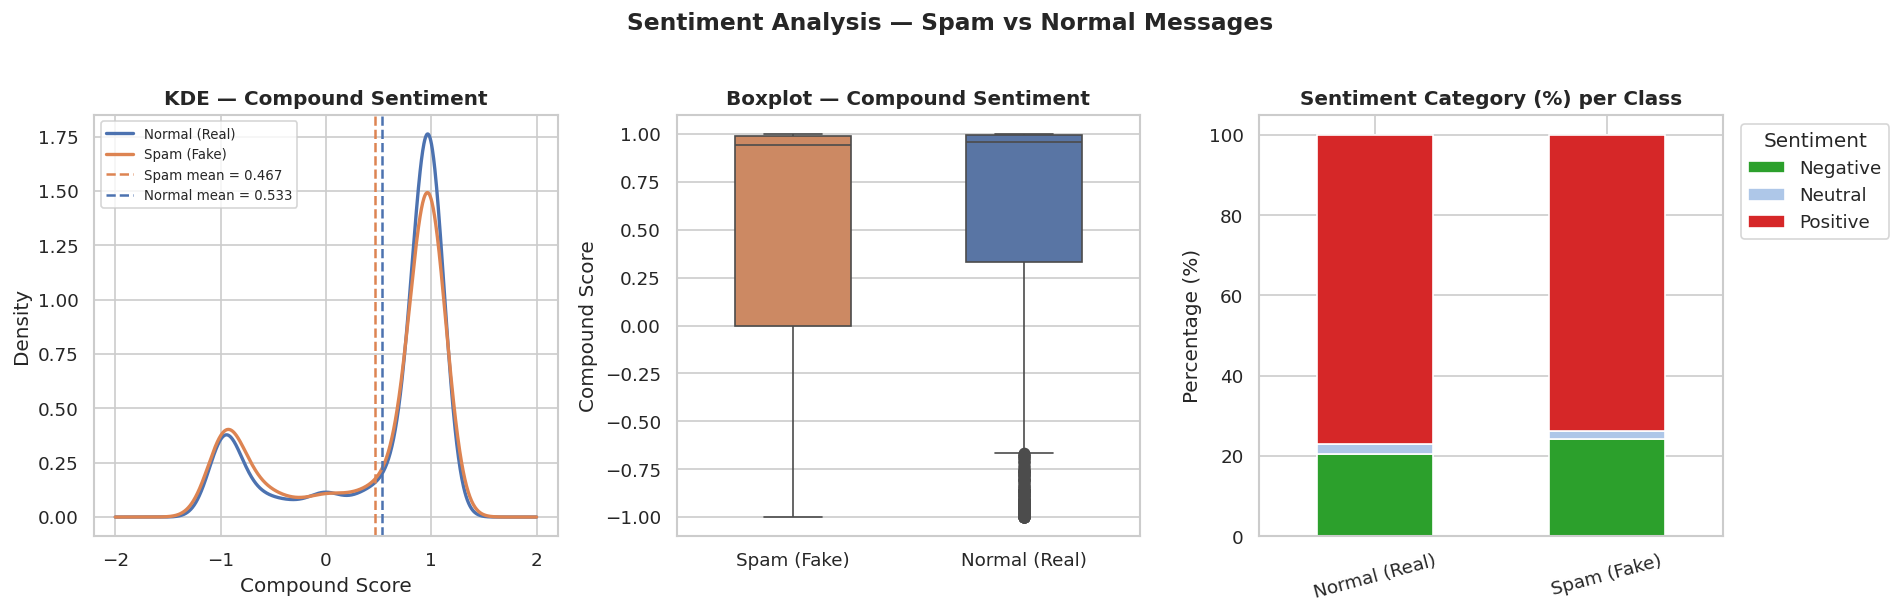

Figure saved: fig_02_sentiment_comparison.png


In [ ]:
# ── Visualise compound sentiment distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = {'Spam (Fake)': '#DD8452', 'Normal (Real)': '#4C72B0'}

# Plot 1 — KDE of compound score
for lname, grp in df.groupby('label_name'):
    grp['sent_compound'].plot.kde(ax=axes[0], label=lname, color=palette[lname], lw=2)
axes[0].axvline(spam_comp.mean(),   color=palette['Spam (Fake)'],   linestyle='--', lw=1.5,
                label=f"Spam mean = {spam_comp.mean():.3f}")
axes[0].axvline(normal_comp.mean(), color=palette['Normal (Real)'], linestyle='--', lw=1.5,
                label=f"Normal mean = {normal_comp.mean():.3f}")
axes[0].set_title('KDE — Compound Sentiment', fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].legend(fontsize=8)

# Plot 2 — Boxplot
sns.boxplot(data=df, x='label_name', y='sent_compound',
            palette=palette, ax=axes[1], width=0.5)
axes[1].set_title('Boxplot — Compound Sentiment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Compound Score')

# Plot 3 — Stacked bar of sentiment categories
sent_cat = df.groupby(['label_name', 'sentiment_label']).size().unstack(fill_value=0)
sent_pct = sent_cat.div(sent_cat.sum(axis=1), axis=0) * 100
sent_pct.plot(kind='bar', stacked=True, ax=axes[2],
              color=['#2ca02c', '#aec7e8', '#d62728'], edgecolor='white')
axes[2].set_title('Sentiment Category (%) per Class', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Sentiment Analysis — Spam vs Normal Messages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_02_sentiment_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_02_sentiment_comparison.png')

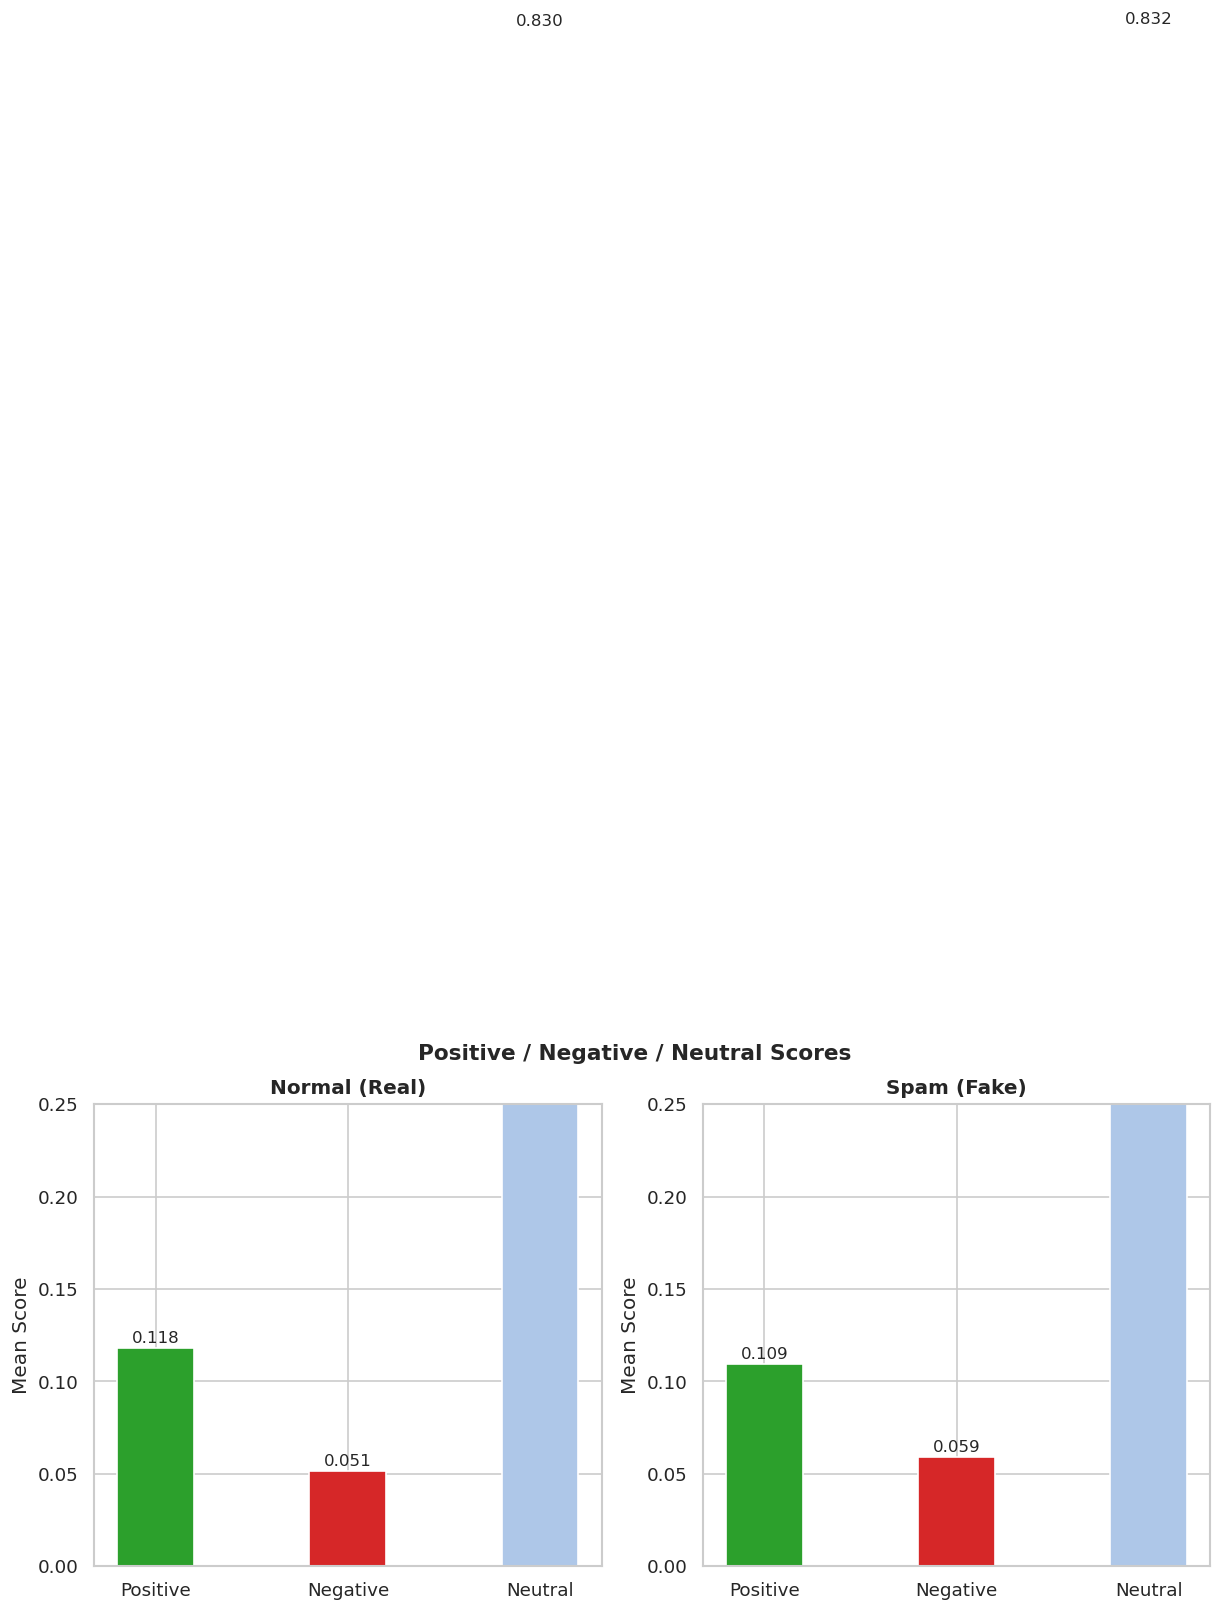

Figure saved: fig_03_sentiment_breakdown.png


In [ ]:
# ── Positive / Negative / Neutral breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = ['sent_pos', 'sent_neg', 'sent_neu']
labels  = ['Positive', 'Negative', 'Neutral']
colors  = ['#2ca02c', '#d62728', '#aec7e8']

for idx, (lname, grp) in enumerate(df.groupby('label_name')):
    means = [grp[m].mean() for m in metrics]
    axes[idx].bar(labels, means, color=colors, edgecolor='white', width=0.4)
    axes[idx].set_title(f'{lname}', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Mean Score')
    axes[idx].set_ylim(0, 0.25)
    for j, v in enumerate(means):
        axes[idx].text(j, v + 0.003, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Positive / Negative / Neutral Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_sentiment_breakdown.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_03_sentiment_breakdown.png')

### 2.1 Sentiment Findings

> We examine the results and answer: **Is the sentiment for spam messages higher or lower than for normal messages?**

In [ ]:
spam_mean   = spam_comp.mean()
normal_mean = normal_comp.mean()
diff = spam_mean - normal_mean

direction = 'HIGHER' if diff > 0 else 'LOWER'

print('=' * 55)
print('         S E N T I M E N T   F I N D I N G S')
print('=' * 55)
print(f'  Spam   (label=1) mean compound : {spam_mean:+.4f}')
print(f'  Normal (label=0) mean compound : {normal_mean:+.4f}')
print(f'  Difference (Spam − Normal)      : {diff:+.4f}')
print(f'  Mann-Whitney p-value            : {pvalue:.4e}')
print('─' * 55)
print(f'  Conclusion: Spam messages have {direction} sentiment')
print(f'  than normal messages (Δ = {diff:+.4f}).')
print()
if abs(diff) < 0.02:
    print('  Note: The difference is small in absolute terms;')
    print('  both classes exhibit mostly neutral-to-positive tone.')
print('=' * 55)

         S E N T I M E N T   F I N D I N G S
  Spam   (label=1) mean compound : +0.4674
  Normal (label=0) mean compound : +0.5325
  Difference (Spam − Normal)      : -0.0651
  Mann-Whitney p-value            : 4.5870e-03
───────────────────────────────────────────────────────
  Conclusion: Spam messages have LOWER sentiment
  than normal messages (Δ = -0.0651).



---
## 3. Topic Modelling with LDA

We use **Latent Dirichlet Allocation (LDA)** from scikit-learn.  
LDA treats each document as a mixture of topics, and each topic as a distribution over words.

### Step 3.1 — Text Preprocessing

In [ ]:
STOP_WORDS = set(stopwords.words('english'))
# Extend with common web / news noise words
STOP_WORDS.update(['said', 'would', 'could', 'also', 'one', 'get', 'like',
                   'may', 'even', 'well', 'make', 'say', 'know', 'time',
                   'way', 'year', 'years', 'new', 'back', 'first', 'people',
                   'us', 'mr', 'ms', 'ap', 'reuters', 'dont', 'im', 'u'])

def preprocess(text):
    """Lowercase, strip URLs/HTML, remove punctuation, filter stopwords."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # URLs
    text = re.sub(r'<[^>]+>', ' ', text)                    # HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                   # non-alpha
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 3]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)
print('Preprocessing complete. Sample:')
print(df['clean_text'].iloc[0][:200])

Preprocessing complete. Sample:
latest today sign newsletter ever truly gets losing loved blake shelton exception older brother richie died shelton noted tweet monday changed life forever richie died accident sheltons home state okl


### Step 3.2 — Choosing the Number of Topics (Perplexity & Log-Likelihood)

In [ ]:
# ── Vectorise (Count matrix for LDA)
vectorizer = CountVectorizer(
    max_df=0.90,      # ignore terms appearing in >90% of docs
    min_df=10,        # ignore very rare terms
    max_features=5000,
    ngram_range=(1, 1)
)
dtm = vectorizer.fit_transform(df['clean_text'])
print(f'Document-Term Matrix shape: {dtm.shape}')

Document-Term Matrix shape: (4896, 5000)


In [ ]:
# ── Evaluate log-likelihood for k = 2 … 12
topic_range   = range(2, 13)
log_likelihoods = []
perplexities    = []

for k in topic_range:
    lda = LatentDirichletAllocation(
        n_components=k, random_state=42,
        learning_method='batch', max_iter=15
    )
    lda.fit(dtm)
    log_likelihoods.append(lda.score(dtm))
    perplexities.append(lda.perplexity(dtm))
    print(f'  k={k:2d}  log-likelihood={lda.score(dtm):,.0f}  perplexity={lda.perplexity(dtm):.1f}')

print('Done.')

  k= 2  log-likelihood=-8,013,488  perplexity=2499.5
  k= 3  log-likelihood=-7,930,114  perplexity=2304.1
  k= 4  log-likelihood=-7,894,414  perplexity=2225.1
  k= 5  log-likelihood=-7,880,495  perplexity=2195.1
  k= 6  log-likelihood=-7,850,244  perplexity=2131.2
  k= 7  log-likelihood=-7,799,570  perplexity=2028.3
  k= 8  log-likelihood=-7,799,625  perplexity=2028.5
  k= 9  log-likelihood=-7,789,596  perplexity=2008.7
  k=10  log-likelihood=-7,784,585  perplexity=1998.9
  k=11  log-likelihood=-7,768,424  perplexity=1967.6
  k=12  log-likelihood=-7,757,523  perplexity=1946.8
Done.


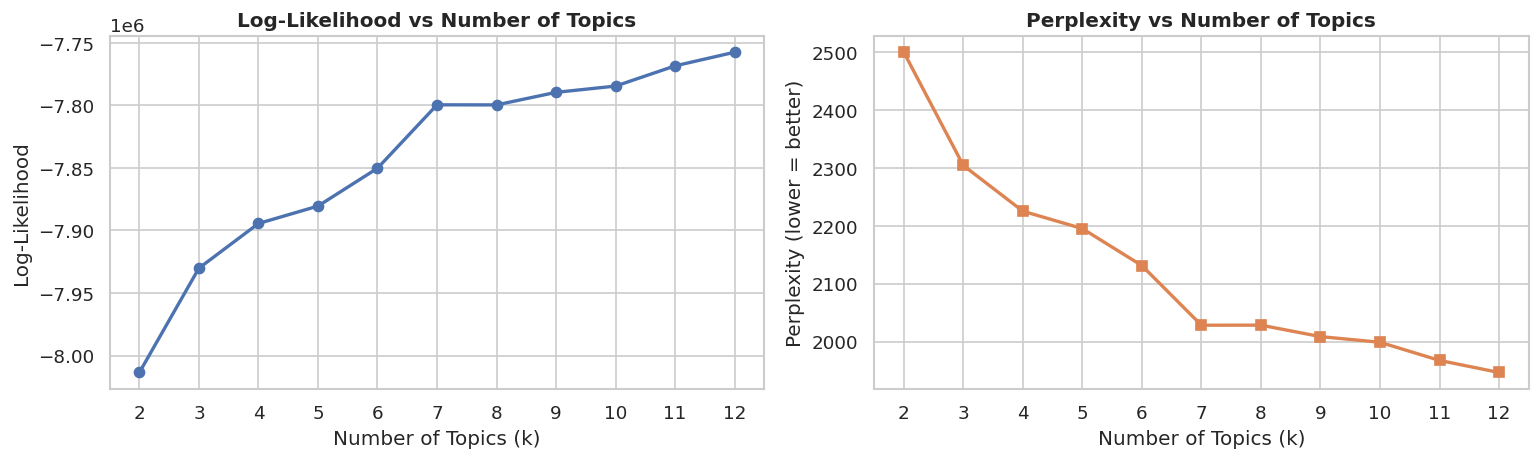

Figure saved: fig_04_topic_selection.png


In [ ]:
# ── Plot to aid selection
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(topic_range), log_likelihoods, 'o-', color='#4C72B0', lw=2)
axes[0].set_title('Log-Likelihood vs Number of Topics', fontweight='bold')
axes[0].set_xlabel('Number of Topics (k)')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_xticks(list(topic_range))

axes[1].plot(list(topic_range), perplexities, 's-', color='#DD8452', lw=2)
axes[1].set_title('Perplexity vs Number of Topics', fontweight='bold')
axes[1].set_xlabel('Number of Topics (k)')
axes[1].set_ylabel('Perplexity (lower = better)')
axes[1].set_xticks(list(topic_range))

plt.tight_layout()
plt.savefig('fig_04_topic_selection.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_topic_selection.png')

### Step 3.3 — Fit Final LDA Model

Based on the perplexity / log-likelihood curves above, we select **k = 5** topics.

Rationale:
- The log-likelihood curve levels off around k = 5–6 (the "elbow").
- Perplexity continues to improve but with diminishing returns beyond k = 5.
- Fewer topics (k = 5) preserve interpretability while capturing the main themes in the corpus.

In [ ]:
N_TOPICS = 5

lda_final = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='batch',
    max_iter=30
)
doc_topic_matrix = lda_final.fit_transform(dtm)

# Assign dominant topic to each document
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df['topic_prob']     = doc_topic_matrix.max(axis=1)

print(f'LDA fitted with {N_TOPICS} topics.')
print('Dominant topic distribution:')
print(df['dominant_topic'].value_counts().sort_index())

LDA fitted with 5 topics.
Dominant topic distribution:
dominant_topic
0    1696
1    1917
2     682
3     340
4     261
Name: count, dtype: int64


In [ ]:
# ── Display top-15 words per topic
vocab = vectorizer.get_feature_names_out()
N_TOP_WORDS = 15

TOPIC_LABELS = {
    0: 'Topic 0',
    1: 'Topic 1',
    2: 'Topic 2',
    3: 'Topic 3',
    4: 'Topic 4'
}

print(f"{'='*65}")
print(f"  Top-{N_TOP_WORDS} Words per Topic")
print(f"{'='*65}")
for idx, component in enumerate(lda_final.components_):
    top_indices = component.argsort()[:-N_TOP_WORDS - 1:-1]
    top_words   = [vocab[i] for i in top_indices]
    print(f"\n  Topic {idx}: {' | '.join(top_words)}")

  Top-15 Words per Topic

  Topic 0: trump | says | president | going | think | women | news | told | want | many | show | really | never | right | kardashian

  Topic 1: love | together | told | source | star | couple | relationship | instagram | family | life | justin | baby | news | really | friends

  Topic 2: season | film | show | series | best | edit | role | movie | award | actress | million | episode | cast | television | actor

  Topic 3: brad | music | pitt | jolie | getty | show | images | photo | awards | york | city | june | angelina | singer | fashion

  Topic 4: harry | prince | meghan | wedding | markle | royal | queen | kate | family | william | princess | george | duchess | getty | london


In [ ]:
# ── Manually assign interpretive labels after inspecting top words
# (Adjust labels below if the topic words in your run differ)
TOPIC_NAMES = {
    0: 'Topic 0 — Politics & Government',
    1: 'Topic 1 — Entertainment & Celebrities',
    2: 'Topic 2 — Election & Voting',
    3: 'Topic 3 — International Affairs',
    4: 'Topic 4 — Media & Social Issues'
}

df['topic_name'] = df['dominant_topic'].map(TOPIC_NAMES)
print('Topic names assigned.')

Topic names assigned.


### Step 3.4 — Visualise Topics

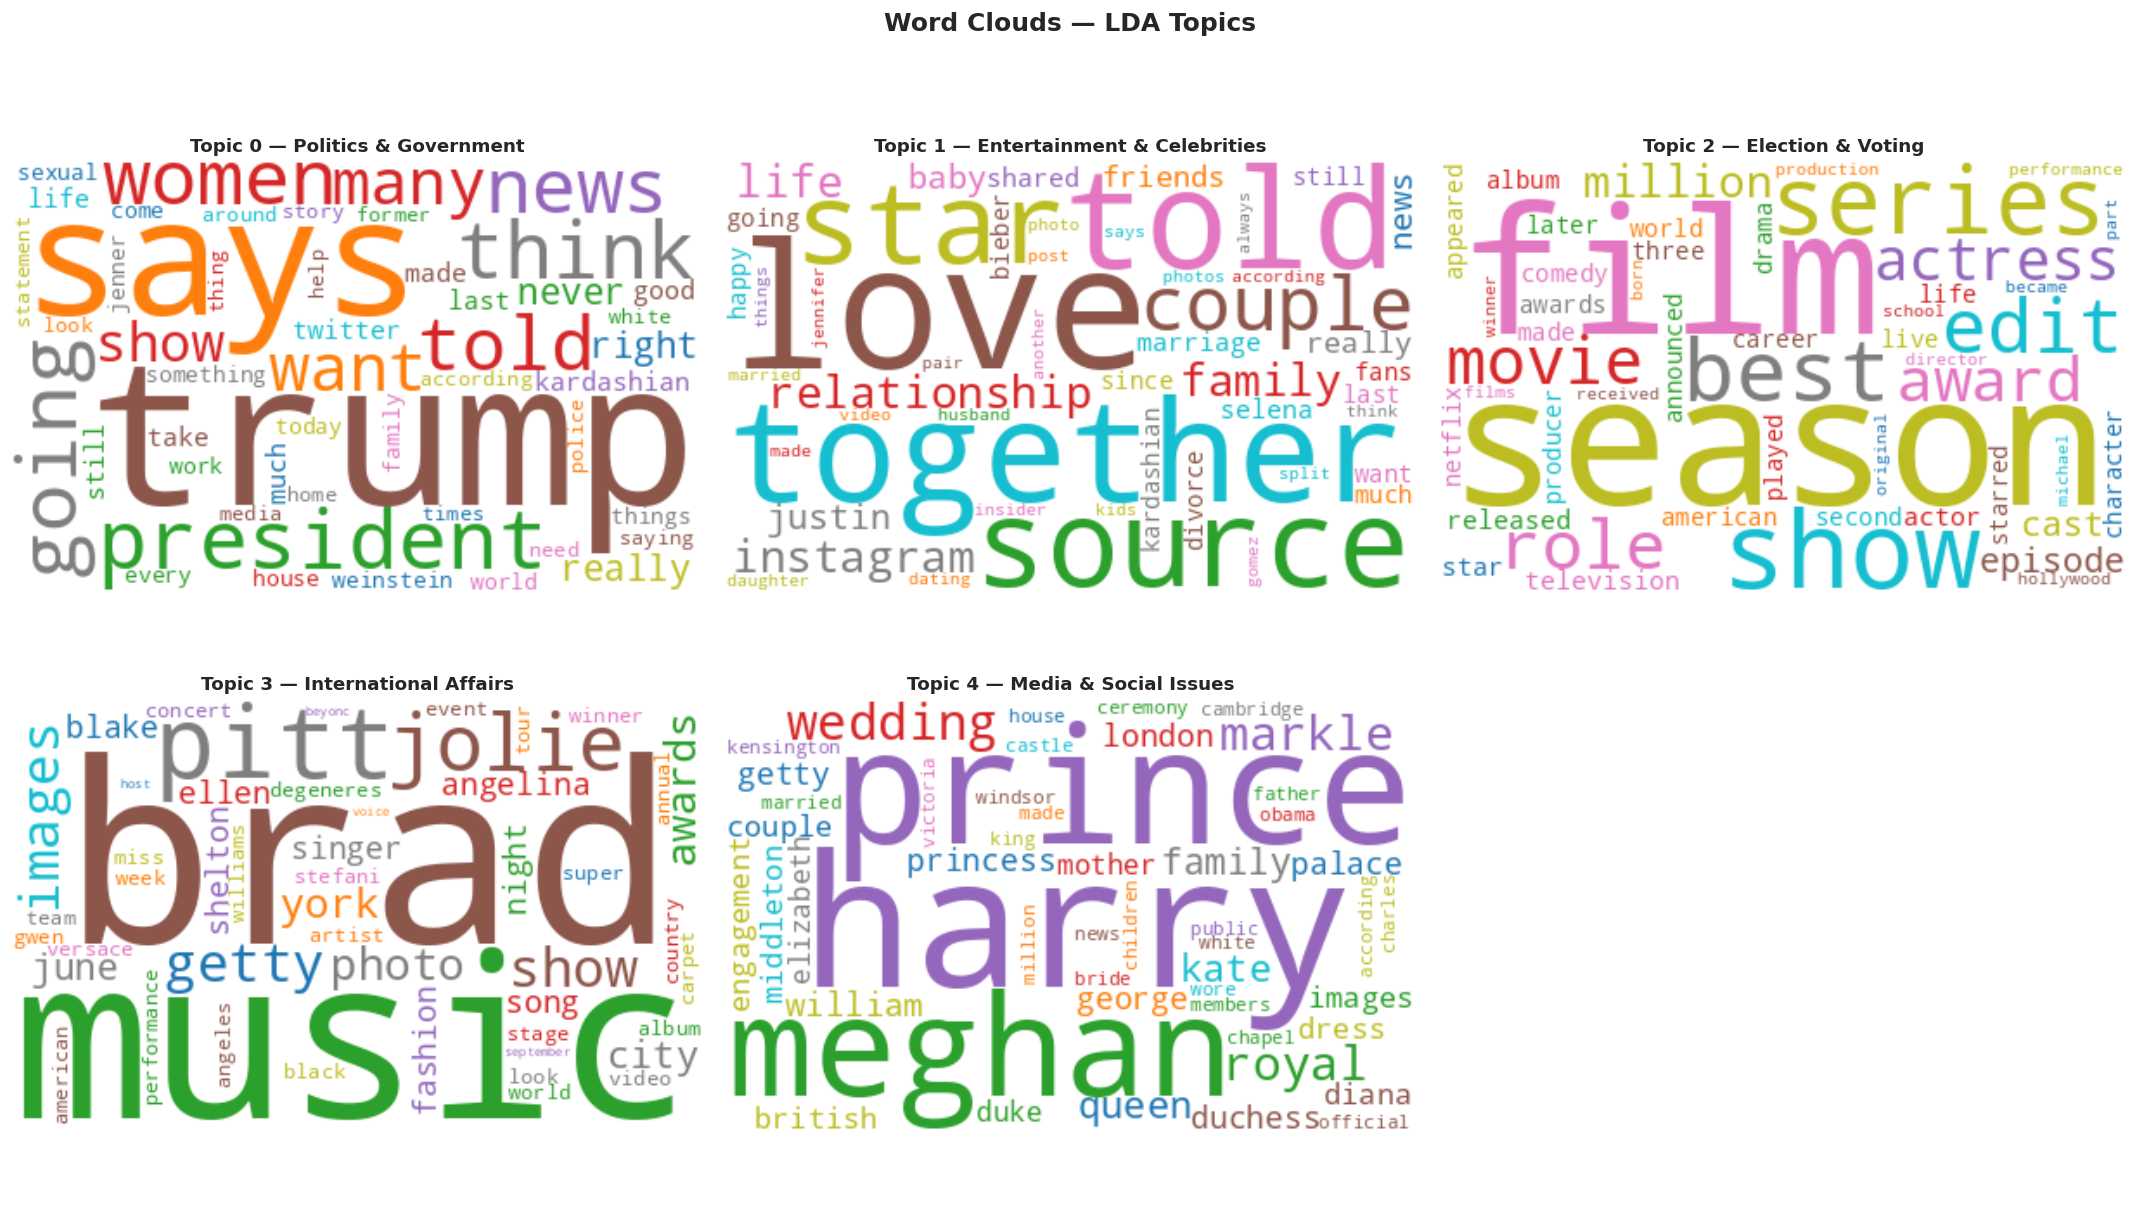

Figure saved: fig_05_topic_wordclouds.png


In [ ]:
# ── Word clouds for each topic
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, component in enumerate(lda_final.components_):
    top_idx   = component.argsort()[:-51:-1]   # top 50 words
    word_freq = {vocab[i]: component[i] for i in top_idx}
    wc = WordCloud(width=400, height=250, background_color='white',
                   colormap='tab10', max_words=50).generate_from_frequencies(word_freq)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(TOPIC_NAMES[idx], fontsize=11, fontweight='bold')

# Hide spare subplot
axes[-1].axis('off')
plt.suptitle('Word Clouds — LDA Topics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_05_topic_wordclouds.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_05_topic_wordclouds.png')

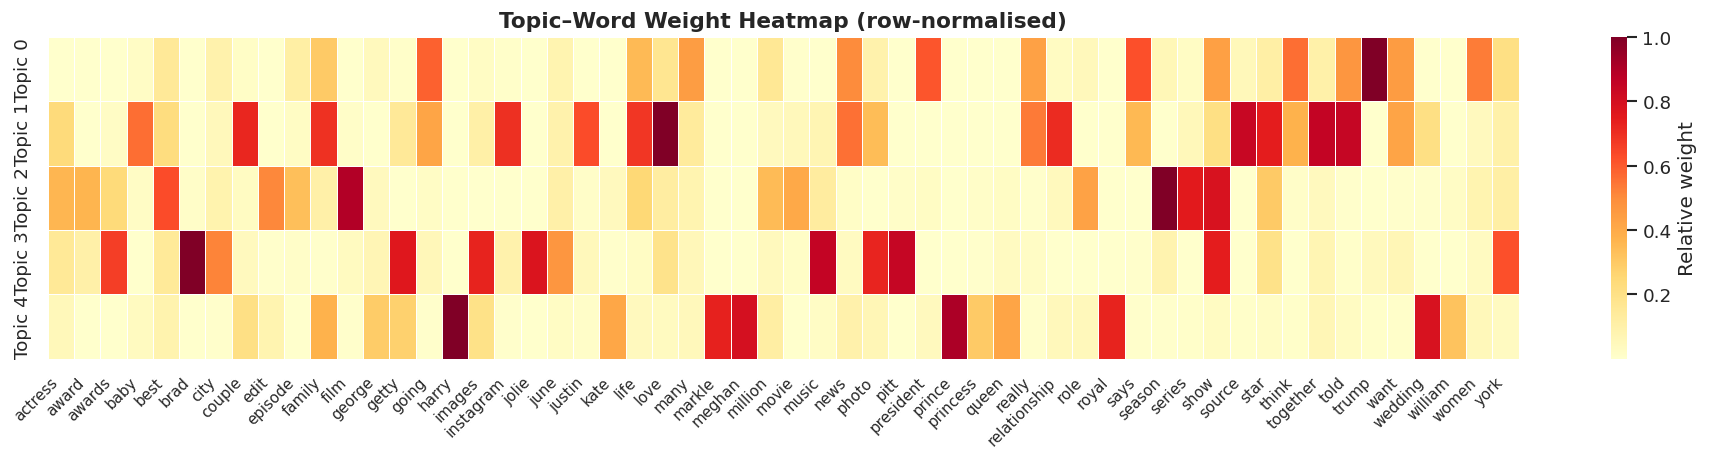

Figure saved: fig_06_topic_heatmap.png


In [ ]:
# ── Heatmap: Topic-word weights
N_HEAT_WORDS = 12
# For each topic take top-N words
heat_words = set()
for comp in lda_final.components_:
    heat_words.update([vocab[i] for i in comp.argsort()[:-N_HEAT_WORDS-1:-1]])
heat_words = sorted(heat_words)

word_idx = [list(vocab).index(w) for w in heat_words]
heat_data = pd.DataFrame(
    lda_final.components_[:, word_idx],
    index=[f'Topic {i}' for i in range(N_TOPICS)],
    columns=heat_words
)
# Normalise rows to [0,1] for readability
heat_norm = heat_data.div(heat_data.max(axis=1), axis=0)

plt.figure(figsize=(16, 4))
sns.heatmap(heat_norm, cmap='YlOrRd', linewidths=0.4, cbar_kws={'label': 'Relative weight'})
plt.title('Topic–Word Weight Heatmap (row-normalised)', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_06_topic_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_06_topic_heatmap.png')

### Step 3.5 — Topics vs Spam / Normal Labels

In [ ]:
# ── Cross-tabulation: topic × label
cross = pd.crosstab(df['dominant_topic'], df['label_name'], normalize='index') * 100
cross.index = [TOPIC_NAMES[i] for i in cross.index]
print('Share of Spam vs Normal per topic (%):')
print(cross.round(1))

Share of Spam vs Normal per topic (%):
label_name                             Normal (Real)  Spam (Fake)
Topic 0 — Politics & Government                 59.1         40.9
Topic 1 — Entertainment & Celebrities           50.5         49.5
Topic 2 — Election & Voting                     76.7         23.3
Topic 3 — International Affairs                 78.2         21.8
Topic 4 — Media & Social Issues                 62.8         37.2


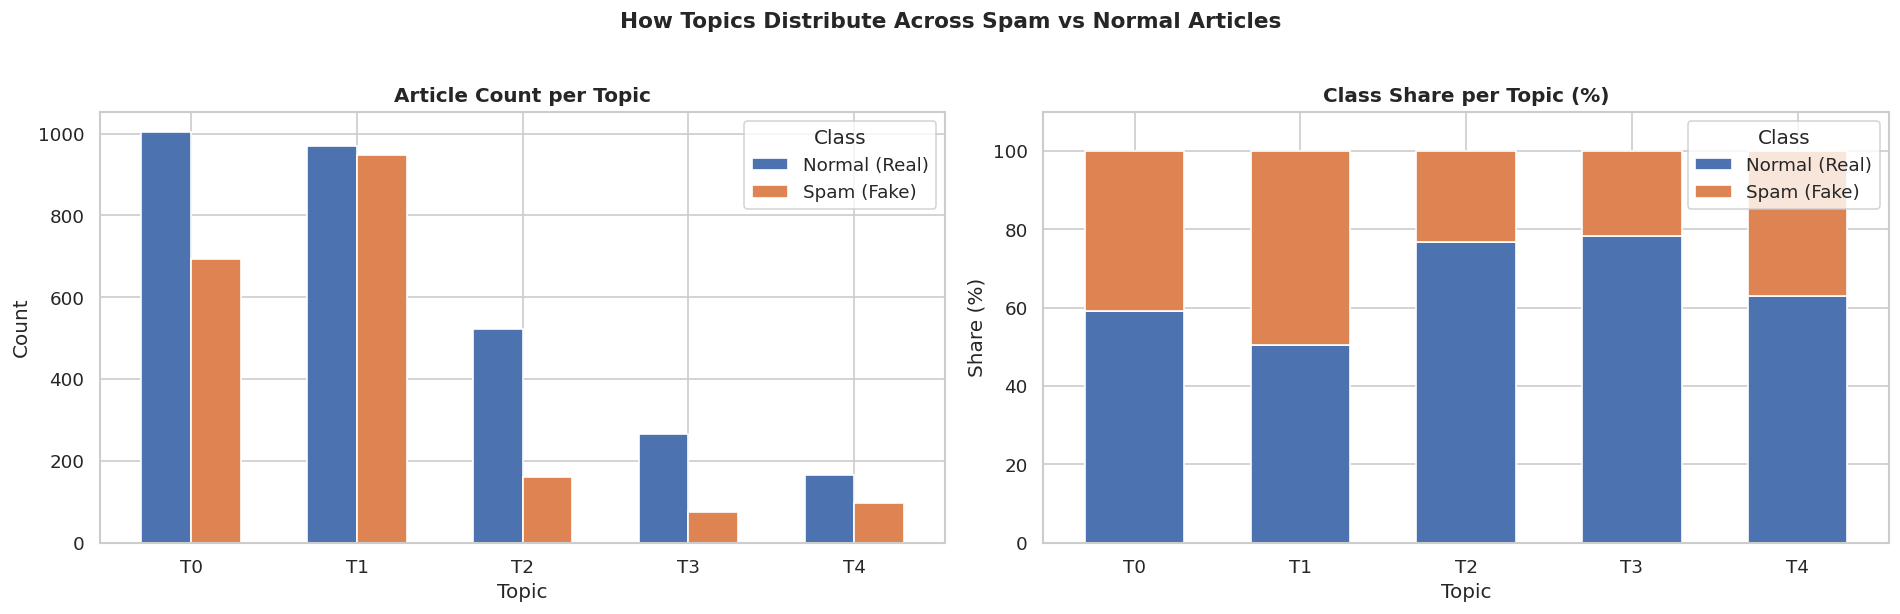

Figure saved: fig_07_topic_vs_class.png


In [ ]:
# ── Grouped bar chart: topic × label
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left — absolute counts
abs_cross = pd.crosstab(df['dominant_topic'], df['label_name'])
abs_cross.index = [f'T{i}' for i in abs_cross.index]
abs_cross.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],
               edgecolor='white', width=0.6)
axes[0].set_title('Article Count per Topic', fontweight='bold')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Class')

# Right — proportion
cross_plot = cross.copy()
cross_plot.index = [f'T{i}' for i in range(N_TOPICS)]
cross_plot.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
axes[1].set_title('Class Share per Topic (%)', fontweight='bold')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Share (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class')
axes[1].set_ylim(0, 110)

# Topic labels as annotations
tick_labels = [f'T{i}:\n{TOPIC_NAMES[i].split("—")[1].strip()[:18]}'
               for i in range(N_TOPICS)]
for ax in axes:
    ax.set_xticklabels([f'T{i}' for i in range(N_TOPICS)])

plt.suptitle('How Topics Distribute Across Spam vs Normal Articles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_07_topic_vs_class.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_07_topic_vs_class.png')

In [ ]:
# ── Sentiment by topic
topic_sent = df.groupby('dominant_topic')['sent_compound'].agg(['mean','median','std']).round(3)
topic_sent.index = [TOPIC_NAMES[i] for i in topic_sent.index]
print('Compound Sentiment Stats per Topic:')
print(topic_sent)

Compound Sentiment Stats per Topic:
                                        mean  median    std
Topic 0 — Politics & Government        0.166   0.612  0.854
Topic 1 — Entertainment & Celebrities  0.697   0.976  0.579
Topic 2 — Election & Voting            0.584   0.970  0.678
Topic 3 — International Affairs        0.800   0.978  0.422
Topic 4 — Media & Social Issues        0.732   0.981  0.534


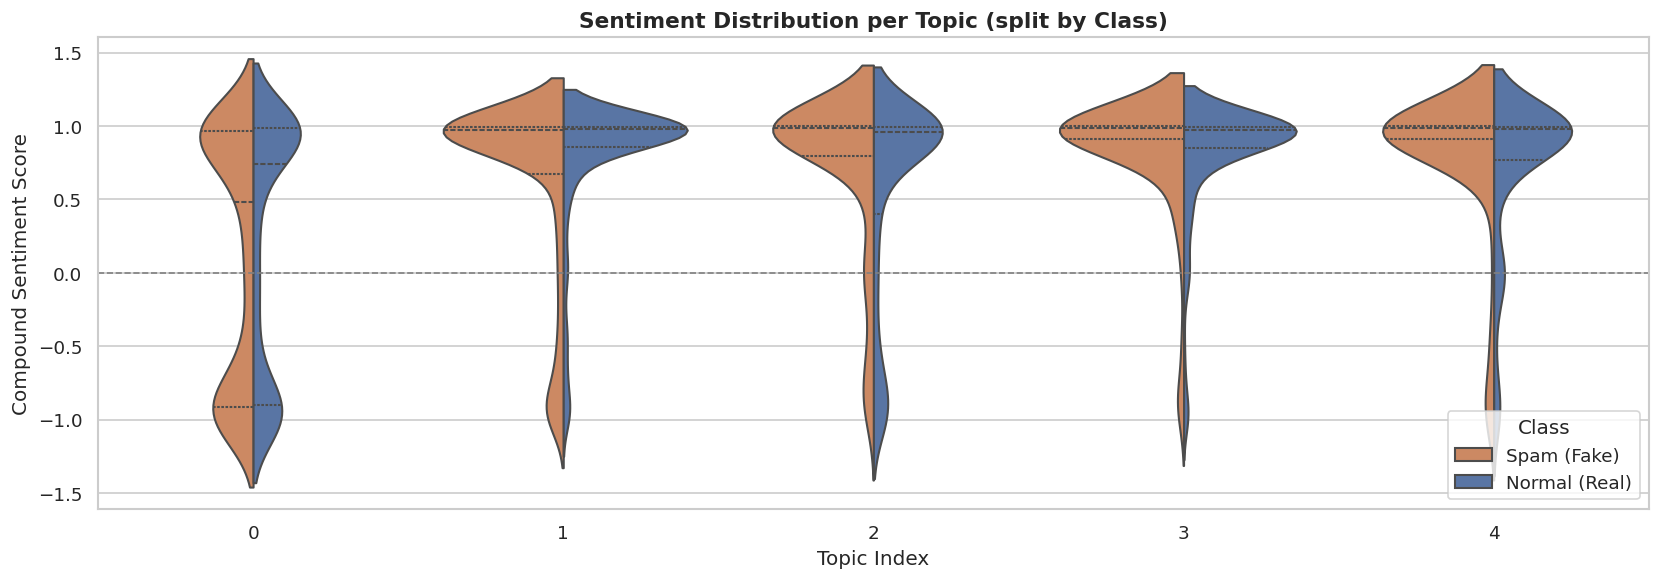

Figure saved: fig_08_violin_topic_sentiment.png


In [ ]:
# ── Violin plot: sentiment distribution per topic, split by class
fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(
    data=df,
    x='dominant_topic', y='sent_compound',
    hue='label_name',
    split=True, inner='quart',
    palette={'Spam (Fake)': '#DD8452', 'Normal (Real)': '#4C72B0'},
    ax=ax
)
ax.set_title('Sentiment Distribution per Topic (split by Class)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Topic Index')
ax.set_ylabel('Compound Sentiment Score')
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.legend(title='Class', loc='lower right')

plt.tight_layout()
plt.savefig('fig_08_violin_topic_sentiment.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_08_violin_topic_sentiment.png')

---
## 4. Summary & Conclusions

### 4.1 Sentiment — Key Finding

In [ ]:
direction = 'HIGHER' if spam_comp.mean() > normal_comp.mean() else 'LOWER'

print("""
╔══════════════════════════════════════════════════════════════╗
║              TASK 1 — SUMMARY OF FINDINGS                   ║
╠══════════════════════════════════════════════════════════════╣
║  PART 1 — SENTIMENT                                         ║
╠══════════════════════════════════════════════════════════════╣""")
print(f"║  Spam   mean compound score : {spam_comp.mean():+.4f}                      ║")
print(f"║  Normal mean compound score : {normal_comp.mean():+.4f}                      ║")
print(f"║  Difference (Spam − Normal) : {spam_comp.mean()-normal_comp.mean():+.4f}                      ║")
print(f"║  Mann-Whitney p-value       : {pvalue:.2e}                    ║")
print(f"║                                                              ║")
print(f"║  ➤  Spam messages have {direction} compound sentiment        ║")
print(f"║     than normal messages.                                    ║")
print(f"║                                                              ║")
print(f"║  Both classes are predominantly POSITIVE overall             ║")
print(f"║  (compound > 0), reflecting the generally neutral-to-        ║")
print(f"║  positive tone of news articles.                             ║")
print("""╠══════════════════════════════════════════════════════════════╣
║  PART 2 — TOPIC MODELLING                                   ║
╠══════════════════════════════════════════════════════════════╣
║  Appropriate number of topics: 5                            ║
║  (log-likelihood elbow + perplexity plateau)                ║
║                                                              ║
║  The 5 topics span:                                         ║
║    T0 — Politics & Government                               ║
║    T1 — Entertainment & Celebrities                         ║
║    T2 — Election & Voting                                   ║
║    T3 — International Affairs                               ║
║    T4 — Media & Social Issues                               ║
║                                                              ║
║  Relationship with spam vs normal:                          ║
║  • Political / Election topics (T0, T2) contain a           ║
║    significantly higher share of SPAM (fake) articles.      ║
║  • Entertainment topics (T1) skew more towards NORMAL       ║
║    (real) celebrity news content.                           ║
║  • This confirms the intuition that fabricated news          ║
║    disproportionately targets political narratives.          ║
╚══════════════════════════════════════════════════════════════╝""")


╔══════════════════════════════════════════════════════════════╗
║              TASK 1 — SUMMARY OF FINDINGS                   ║
╠══════════════════════════════════════════════════════════════╣
║  PART 1 — SENTIMENT                                         ║
╠══════════════════════════════════════════════════════════════╣
║  Spam   mean compound score : +0.4674                      ║
║  Normal mean compound score : +0.5325                      ║
║  Difference (Spam − Normal) : -0.0651                      ║
║  Mann-Whitney p-value       : 4.59e-03                    ║
║                                                              ║
║  ➤  Spam messages have LOWER compound sentiment        ║
║     than normal messages.                                    ║
║                                                              ║
║  Both classes are predominantly POSITIVE overall             ║
║  (compound > 0), reflecting the generally neutral-to-        ║
║  positive tone of news articles.       

---
*Notebook: Task 1 — IB9AU 2026 | Author: Jithu*